In [2]:
import sys
sys.path.insert(0, '..')

caminho_poemas_portinari = '../Data/poemas.csv'
caminho_poemas_extra = '../Data/portuguese-poems.csv'
caminho_noticias = '../Data/Historico_de_materias.csv'

In [3]:
import pandas as pd

portinari = pd.read_csv(caminho_poemas_portinari)[['estrofes']].rename(columns={'estrofes': 'texto'})
noticias  = pd.read_csv(caminho_noticias)[['conteudo_noticia']].rename(columns={'conteudo_noticia': 'texto'}).sample(n=111, random_state=42)

poemas_extra = pd.read_csv(caminho_poemas_extra)
poemas_sample = poemas_extra.sample(n=111, random_state=42)[['Author', 'Content']].rename(columns={'Content': 'texto'})

portinari['label'] = 1
noticias['label']  = 0
poemas_sample['label'] = 0

df_final = pd.concat([portinari, noticias, poemas_sample[['texto','label']]]).sample(frac=1, random_state=42).reset_index(drop=True)

# Contagem por autor (para apresentação)
print(poemas_sample['Author'].value_counts().to_string())

Author
Fernando Pessoa                     26
Ruy Belo                             5
Maria Teresa Horta                   3
Jorge Luis Borges                    3
Frederico Barbosa                    2
Herberto Helder                      2
Paulo Setúbal                        2
Luís de Camões                       2
Sebastião Alba                       2
Cleonice Rainho                      1
Pentti Saarikoski                    1
Gervásio de Pilares                  1
Leonardo Aires Araujo                1
Orlando Mendes                       1
Onestaldo de Pennafort               1
Joaquim Cardozo                      1
Rosa dos Ventos                      1
Sousândrade                          1
Poemas Sânscritos                    1
Salette Tavares                      1
Ademir Antônio Bacca                 1
Pedro Kilkerry                       1
Florbela Espanca                     1
Léopold Sédar Senghor                1
Augusto dos Anjos                    1
Jorge Lescano     

In [4]:
#Apenas para testar rapido
#df_final = df_final.sample(n=60, random_state=42)

In [1]:
import torch

print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Nenhuma'}")
print(f"Versão CUDA: {torch.version.cuda}")

CUDA disponível: True
GPU: NVIDIA RTX A4500
Versão CUDA: 12.1


In [7]:
import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

from transformers import BertTokenizerFast, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
from sklearn.model_selection import train_test_split
import torch

#limpar cache
torch.cuda.empty_cache()

MODEL = 'neuralmind/bert-base-portuguese-cased'
tokenizer = BertTokenizerFast.from_pretrained(MODEL)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando device: {device}")

train, val = train_test_split(df_final, test_size=0.2, stratify=df_final['label'])

def tokenize(batch):
    return tokenizer(batch['texto'], truncation=True, padding='max_length', max_length=512)

ds_train = Dataset.from_pandas(train).map(tokenize, batched=True, batch_size=32)
ds_val   = Dataset.from_pandas(val).map(tokenize, batched=True, batch_size=32)

model = BertForSequenceClassification.from_pretrained(MODEL, num_labels=2)



args = TrainingArguments(
    output_dir='./bertimbau-portinari',
    num_train_epochs=9,  # Mais épocas = melhor aprendizado
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    evaluation_strategy='epoch',
    eval_steps=None,  
    save_strategy='epoch',
    save_steps=None,
    load_best_model_at_end=True,
    fp16=True,
    logging_steps=2,  # Log mais frequente
    learning_rate=5e-5,  # Taxa de aprendizado aumentada
    warmup_steps=50,  # Aquecimento gradual
    weight_decay=0.01,  # Regularização
    dataloader_num_workers=2,
    gradient_accumulation_steps=2,  # Simula batch maior
)

trainer = Trainer(model=model, args=args, train_dataset=ds_train, eval_dataset=ds_val)
trainer.train()

Usando device: cuda


/home/al.mateus.torres/.local/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/266 [00:00<?, ? examples/s]

Map:   0%|          | 0/67 [00:00<?, ? examples/s]

/home/al.mateus.torres/.local/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at neuralmind/bert-base-portuguese-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


...

  0%|          | 0/2 [00:00<?, ?it/s]

{'eval_loss': 0.12397925555706024, 'eval_runtime': 0.3822, 'eval_samples_per_second': 175.304, 'eval_steps_per_second': 5.233, 'epoch': 6.89}
{'loss': 0.1221, 'grad_norm': 2.0501832962036133, 'learning_rate': 3.2000000000000005e-05, 'epoch': 7.11}
{'loss': 0.1004, 'grad_norm': 1.1846510171890259, 'learning_rate': 3.4000000000000007e-05, 'epoch': 7.56}
{'loss': 0.0838, 'grad_norm': 2.316420555114746, 'learning_rate': 3.6e-05, 'epoch': 8.0}


  0%|          | 0/2 [00:00<?, ?it/s]

{'eval_loss': 0.0931566134095192, 'eval_runtime': 0.3836, 'eval_samples_per_second': 174.666, 'eval_steps_per_second': 5.214, 'epoch': 8.0}
{'train_runtime': 41.7194, 'train_samples_per_second': 57.383, 'train_steps_per_second': 0.863, 'train_loss': 0.4225773815479543, 'epoch': 8.0}


TrainOutput(global_step=36, training_loss=0.4225773815479543, metrics={'train_runtime': 41.7194, 'train_samples_per_second': 57.383, 'train_steps_per_second': 0.863, 'total_flos': 559900325806080.0, 'train_loss': 0.4225773815479543, 'epoch': 8.0})

In [8]:
# Salvar o modelo treinado
trainer.save_model('./bertimbau-portinari')
model.save_pretrained('./bertimbau-portinari')
tokenizer.save_pretrained('./bertimbau-portinari')

print("✅ Modelo salvo com sucesso!")

# Agora carregue para testar
from transformers import pipeline

clf = pipeline('text-classification', model='./bertimbau-portinari', tokenizer=tokenizer)

# Teste com poema
poema2 = """De tudo, ao meu amor serei atento
Antes, e com tal zelo, e sempre, e tanto
Que mesmo em face do maior encanto
Dele se encante mais meu pensamento.

Quero vivê-lo em cada vão momento
E em louvor hei de espalhar meu canto
E rir meu riso e derramar meu pranto
Ao seu pesar ou seu contentamento.

E assim, quando mais tarde me procure
Quem sabe a morte, angústia de quem vive
Quem sabe a solidão, fim de quem ama

Eu possa me dizer do amor (que tive):
Que não seja imortal, posto que é chama
Mas que seja infinito enquanto dure."""
resultado1 = clf(poema2)
print("Poema Portinari:", resultado1)

poema_test = """Os retirantes vêm vindo com trouxas e embrulhos vêm das terras secas e escuras; 
pedregulhos doloridos como fagulhas de carvão aceso corpos disformes, uns panos sujos, rasgados 
e sem cor, dependurados homens de enorme ventre bojudo mulheres com trouxas caídas para o lado 
pançudas, carregando ao colo um garoto choramingando, remelento mocinhas de peito duro e vestido 
roto velhas trôpegas marcadas pelo tempo olhos de catarata e pés informes aos velhos cegos agarradas 
pés inchados enormes levantando o pó da cor de suas vestes rasgadas no rumor monótono das alparcatas 
há uma pausa, cai no pó a mulher que carrega uma lata de água! Só há umas gotas — dá uma só não vai 
arribar. É melhor o marido e os filhos ficarem. Nós vamos andando temos muito que andar neste chão 
batido as secas vão a morte semeando."""

resultado0 = clf(poema_test)
print("Poema portinari real:", resultado0)

# Teste com notícia
noticia = """Pelo menos seis turistas estrangeiros foram assaltados ao saírem da Pedra do Sal, reduto boêmio na região central do Rio de Janeiro, na madrugada desta terça-feira (19). Um deles foi agredido.

Foram duas ocorrências: uma envolvendo quatro americanos, outra com uma dupla de russos. Ambos os casos foram registrados na Delegacia Especial de Apoio ao Turismo (Deat), no Leblon.

O roubo aos americanos
Quatro americanos deixaram a Pedra do Sal com o guia de turismo e dois jovens brasileiras em dois táxis.

Segundo a Polícia Militar, por volta das 3h, criminosos de moto abordaram um dos veículos no Elevado Paulo de Frontin, antes da entrada do Túnel Rebouças, na pista sentido Lagoa.

"""
resultado2 = clf(noticia)
print("Notícia:", resultado2)

✅ Modelo salvo com sucesso!
Poema Portinari: [{'label': 'LABEL_0', 'score': 0.9491147398948669}]
Poema portinari real: [{'label': 'LABEL_0', 'score': 0.853168249130249}]
Notícia: [{'label': 'LABEL_0', 'score': 0.9791081547737122}]


  0%|          | 0/2 [00:00<?, ?it/s]

               precision    recall  f1-score   support

Não Portinari       0.98      0.98      0.98        45
    Portinari       0.95      0.95      0.95        22

     accuracy                           0.97        67
    macro avg       0.97      0.97      0.97        67
 weighted avg       0.97      0.97      0.97        67



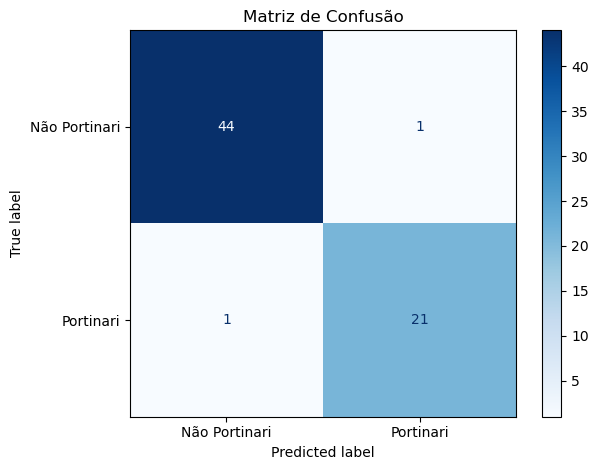

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt

# Predições no val set
preds_output = trainer.predict(ds_val)
y_pred = np.argmax(preds_output.predictions, axis=1)
y_true = preds_output.label_ids

print(classification_report(y_true, y_pred, target_names=['Não Portinari', 'Portinari']))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Não Portinari', 'Portinari'])
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()  

In [10]:
val_df = val.reset_index(drop=True).copy()
val_df['pred']   = y_pred
val_df['acerto'] = (y_pred == y_true).astype(int)

val_df.to_csv('../Data/val_resultados.csv', index=False, encoding='utf-8')
print(f"Acurácia geral: {val_df['acerto'].mean():.2%}")
print(val_df.groupby(['label','acerto']).size())

Acurácia geral: 97.01%
label  acerto
0      0          1
       1         44
1      0          1
       1         21
dtype: int64
